In [1]:
import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)
import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

/kaggle/input/competitions/titanic/train.csv
/kaggle/input/competitions/titanic/test.csv
/kaggle/input/competitions/titanic/gender_submission.csv


In [2]:
# Import Matplotlib an Seaborn for visualization
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
# Import dataset

train_df = pd.read_csv('/kaggle/input/competitions/titanic/train.csv')
test_df = pd.read_csv('/kaggle/input/competitions/titanic/test.csv')

print('Data successfully load')

# Print out of the shape of each dataset
print(f'Train dataset rows: {train_df.shape[0]}')
print(f'Test dataset rows: {test_df.shape[0]}')

Data successfully load
Train dataset rows: 891
Test dataset rows: 418


# 1. Dataset inspection
## 1.1. First inspection on the train dataset

In [4]:
# First inspection
train_df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [5]:
# Get statistics summary (mean, median, std)
train_df.describe()

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,446.000000,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,257.353842,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,1.000000,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,223.500000,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,446.000000,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,668.500000,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,891.000000,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


**Note:** In the fare column there is a big difference between mean and median. Which should be inspected later.

In [6]:
# Checking the dataframe 
train_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


In [7]:
# Count missing values per columns
train_df.isna().sum()

PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64

**Note on the Test Dataset:**  <br>
There are significant missing values in the train dataset.
* The missing values in the 'Age' will be imputed with the grouped title-based median later <br>
* For the missing 'Cabin' values the deck will be extracted later and the missing deck will be replaced with 'U' for 
unknown <br>
* The two missing values in 'Embarked' will be filled with mode() - the most frequent port.

## 1.2. Short inspection of the test dataset

In [8]:
# Checking the head of the test dataset
test_df.head()

,PassengerId,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,892,3,"Kelly, Mr. James",male,34.5,0,0,330911,7.8292,NaN,Q
1,893,3,"Wilkes, Mrs. James (Ellen Needs)",female,47.0,1,0,363272,7.0000,NaN,S
2,894,2,"Myles, Mr. Thomas Francis",male,62.0,0,0,240276,9.6875,NaN,Q
3,895,3,"Wirz, Mr. Albert",male,27.0,0,0,315154,8.6625,NaN,S
4,896,3,"Hirvonen, Mrs. Alexander (Helga E Lindqvist)",female,22.0,1,1,3101298,12.2875,NaN,S


In [9]:
# Checking the test dataframe
test_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 418 entries, 0 to 417
Data columns (total 11 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  418 non-null    int64  
 1   Pclass       418 non-null    int64  
 2   Name         418 non-null    object 
 3   Sex          418 non-null    object 
 4   Age          332 non-null    float64
 5   SibSp        418 non-null    int64  
 6   Parch        418 non-null    int64  
 7   Ticket       418 non-null    object 
 8   Fare         417 non-null    float64
 9   Cabin        91 non-null     object 
 10  Embarked     418 non-null    object 
dtypes: float64(2), int64(4), object(5)
memory usage: 36.1+ KB


In [10]:
# Checking for missing values
test_df.isna().sum()

PassengerId      0
Pclass           0
Name             0
Sex              0
Age             86
SibSp            0
Parch            0
Ticket           0
Fare             1
Cabin          327
Embarked         0
dtype: int64

**Note on Test Dataset:** <br>
Just like the training data, the test dataset contains missing values that require systematic handling before modeling:
* **Age:** Missing values will be imputed using the grouped, title-based medians calculated from the training dataset.
* **Cabin:** The structural 'Deck' letter will be extracted from the cabin number. All missing values will be filled with 'U' for 'Unknown'.
* **Fare:** This will be imputed using the median fare of that passenger's corresponding 'Pclass'.

# 2. Explorative Data Analysis

## 2.1. Survival Rate by Gender

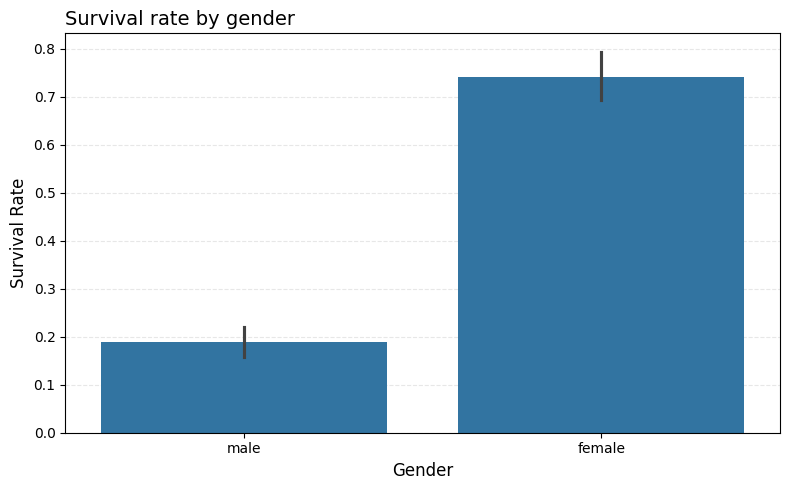

In [11]:
# Visualize the surivial rate by gender
plt.figure(figsize=(8,5))

sns.barplot(data=train_df, x='Sex', y='Survived')
plt.title('Survival rate by gender', fontsize=14, loc='left')
plt.xlabel('Gender', fontsize=12)
plt.ylabel('Survival Rate', fontsize=12)
plt.gca().set_axisbelow(True)
plt.grid(axis='y', linestyle='--', alpha=0.3)

plt.tight_layout()
plt.show()

**Analysis:** The chart clearly reveals a strong contrast in survival rates between genders. Female passengers had a significantly higher survival rate of nearly around 80%. In contrast, male passengers had a survival rate of less than 20%, confirming that they were not prioritized during the lifeboat evacuation.

## 2.2. Survival Rate by Gender and Class

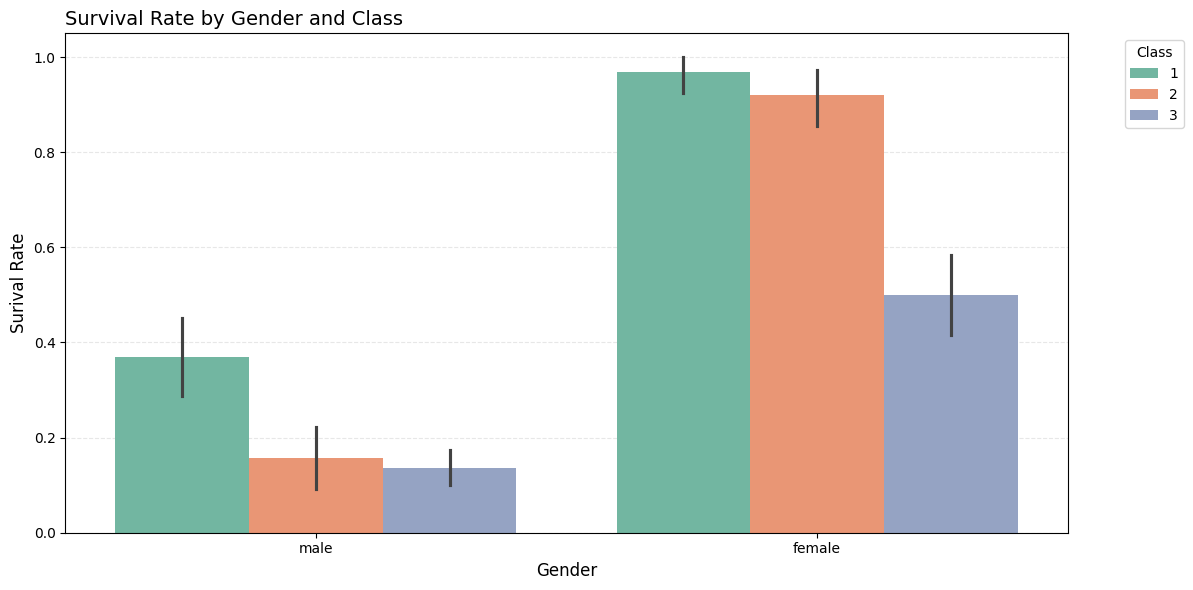

In [12]:
# Visualize the survival rate by gender and class 

plt.figure(figsize=(12,6))
sns.barplot(data=train_df, x='Sex', y='Survived', hue='Pclass', palette='Set2')
plt.title('Survival Rate by Gender and Class', fontsize=14, loc='left')
plt.xlabel('Gender', fontsize=12)
plt.ylabel('Surival Rate', fontsize=12)
plt.gca().set_axisbelow(True)
plt.grid(axis='y', linestyle='--', alpha=0.3)
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', title='Class')

plt.tight_layout()
plt.show()

**Analysis:** The Chart reveals, that women travelling the first and second class had the highest survival rate, with more than 80% in both classes. This indicates that for safety reasons women had a higher priorty to embark on the lifeboats. In contrast, men did not reach 40% in the first class and dropped below 20% in the second and third class. The chart reveals also that the protocol "women and childs first" was strictly followed for passengers travelling in first and second class, whereas passengers travelling in the third class did not have a high survival chance, likley due to their low socioeconomic status.

## 2.3. Survived Passengers by Age Distribution 

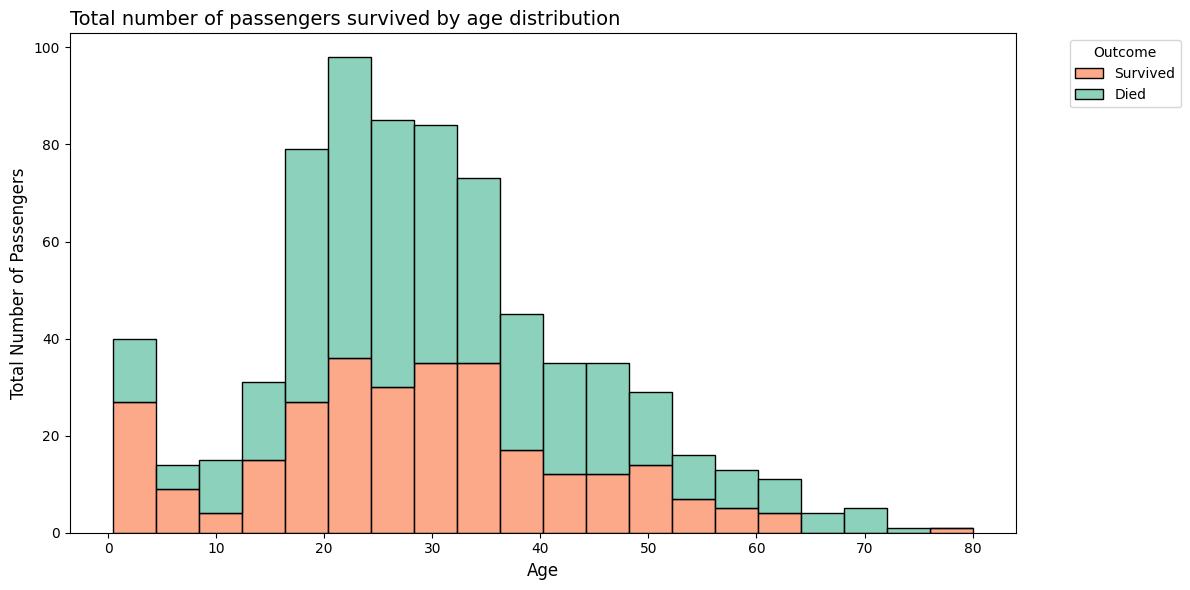

In [13]:
# Question: Does the age have an impact on the survival rate?
# Visualize the total number of passengers survived by age distribution

plt.figure(figsize=(12,6))
sns.histplot(data=train_df, x='Age', hue='Survived', multiple='stack', palette='Set2')
plt.title('Total number of passengers survived by age distribution', fontsize=14, loc='left')
plt.xlabel('Age', fontsize=12)
plt.ylabel('Total Number of Passengers', fontsize=12)
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', title='Outcome', labels=['Survived', 'Died'])

plt.tight_layout()
plt.show()

**Analysis:** The histogram reveals that the majority of passengers were young adults between 20 and 30 years old. Whihin this age group, specifically around 20 and 30, the non-survival count was significant higher than the survival count, which reflects the high number of young passengers travelling. For children under the age of 10, there is a relativley high proportion of survivors, especially among toddlers. However, their survival rate is not 100%, indicating that while 'woman and children first' protocol was generally active, factors like passenger class still limited their rescure Above the age of 40, the total number of passengers decrease noticably.

## 2.4. Survival Rate by Family Size

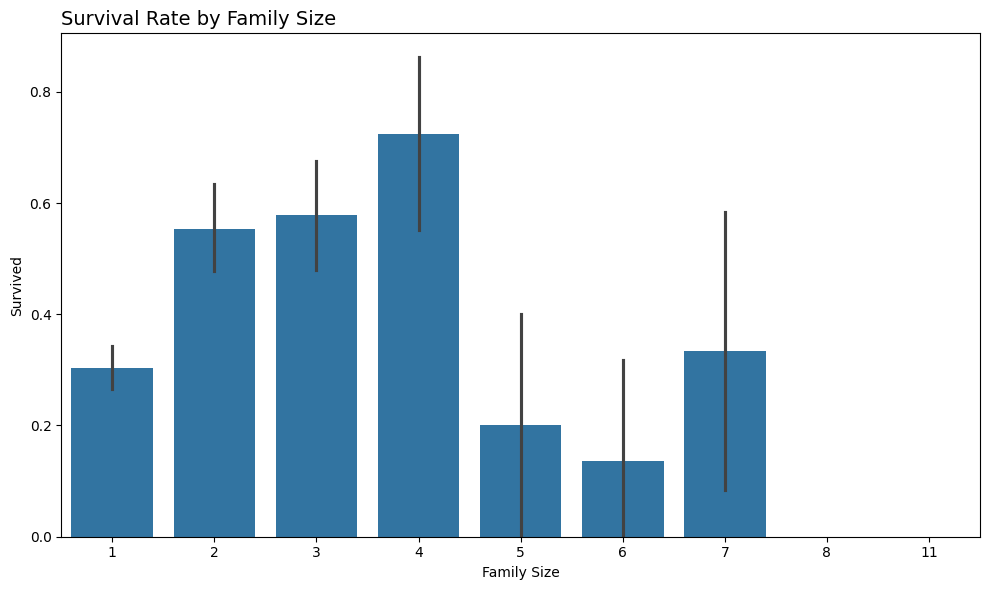

In [14]:
# Adding tempory new column 'FamilySize' to check the survival rate by family size

train_df['FamilySize'] = train_df['SibSp'] + train_df['Parch'] +1
plt.figure(figsize=(10,6))
sns.barplot(data=train_df, x='FamilySize', y='Survived')
plt.title('Survival Rate by Family Size', fontsize=14, loc='left')
plt.xlabel('Family Size')

plt.tight_layout()
plt.show()

# Dropping the column
train_df.drop(columns='FamilySize', inplace=True)

**Analysis:** The chart reveals a non-linear relationship between family size and survival rate, which can be devided into three categories:

1. Solo Travellers (Family Size = 1): Passengers travelling alojne had a significant lower survival rate.
2. Small Families (Family Size = 2-4): This group experienced the highest survival rate. Travelling with a small family likely increased the chance of survival, as family members could be alert and support each other.
3. Large Families (Size > 5): The survival rate drops dramatically for larger families. In a crisis situation, keeping a large group together is extremly difficult.

## 2.5. Survival Rate for Children under 18 by Gender and Class

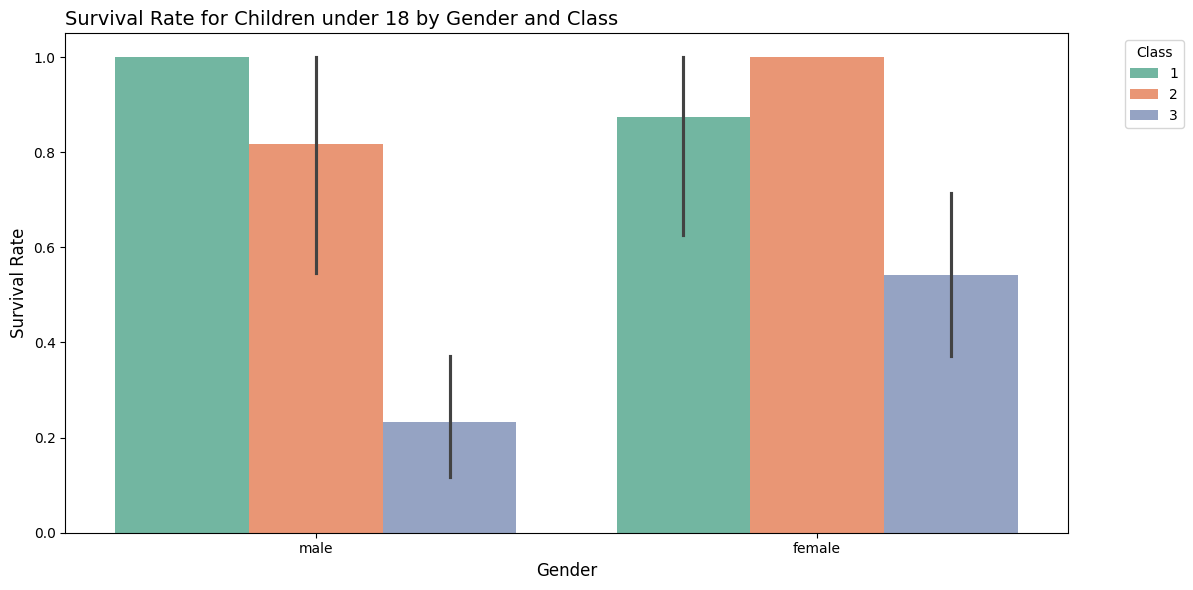

In [15]:
# Question: Was the protocol 'Women and children first' strictly followed?
# Visualize the survival rate by children under the age 18 by class by gender
train_child_df = train_df[train_df['Age'] < 18]

plt.figure(figsize=(12,6))
sns.barplot(data=train_child_df, x='Sex', y='Survived', hue='Pclass', palette='Set2')
plt.title('Survival Rate for Children under 18 by Gender and Class', fontsize=14, loc='left')
plt.xlabel('Gender', fontsize=12)
plt.ylabel('Survival Rate', fontsize=12)
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', title='Class')

plt.tight_layout()
plt.show()

**Analysis:** The Chart reveals that the protocol 'woman and children' first was mostly followed for children in the first and second class. Almost every male children in the first class and all female children in the second class survived. In contrast, male children in the third class had a significant lower surivial rate of around 20%. This indicates that male children passenger had a lower priority for rescue into the lifeboats then female children passenger or faced harder conditions escaping from the lower decks.

## 2.6. Boxplot - Outliers Fares by Class

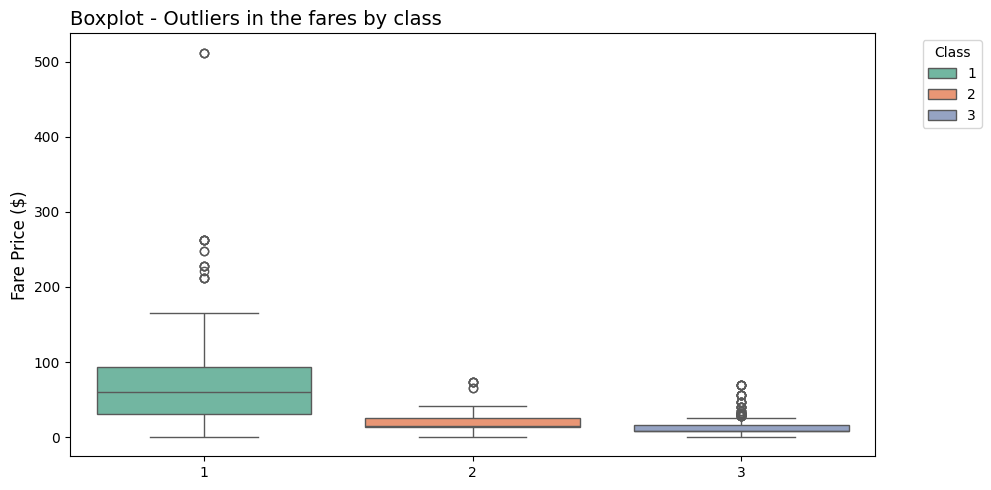

In [16]:
# The statistic inspection from the train_df showed a huge difference between mean and median in the fare tickets.
# Visualize outliers in the fare tickets in the classes

plt.figure(figsize=(10, 5))
sns.boxplot(data=train_df, x='Pclass', y='Fare', hue='Pclass', palette='Set2')
plt.title('Boxplot - Outliers in the fares by class', fontsize=14, loc='left')
plt.xlabel('')
plt.ylabel('Fare Price ($)', fontsize=12)
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', title='Class')

plt.tight_layout()
plt.show()

**Analysis:** The chart illustrate that fare prices in second and third class are mostly consistent and concentrated in a lower, stable price range. This indicates that ticket pricing for these classes followed fixed structure with a little variation. A few slightly higher fares in these classes might be due to late booking or lager family groups sharing a ticket.
In contrast, the first class shows a highly volatile price distribution with significant outliers reaching up to 500$. This massive spread perfectly explains the discrepancy between mean and median observed in the summery statistic above.

## 2.7. Final Key Points

The Analysis shows three primary factors that determind a passengers chance of survival:

* **The 'Woman and Children first' prototol:**
    * Gender is a strong predictor and social norms heavily dictated the evacuation procress
    * Children were protected in first and second class and almost completly saved. However, in the third class faced a drop in the survival rate
* **The Family Size:**
    * Small families (2-4 members): Travelling in small groups significantly increased survival chances, likely because members could alert, look after and support each other
    * Larger families: Larger families faced low survival rate, as keeping large groups together and navigating through the sinking ship was nearly impossible
* **Class & Fares:**
    * First class vs. third class: Ticket class was directly tied to survival. First class pasesngers not only had physical proximity to the boat deck but also priority.
    * Price Volatility: While second and third class tickets followed a stable low price structre, first class fare swere highly volatile with extrem luxury outliers.

# 3. Feature Engineering & Missing Value Imputation

## 3.1. Extracting & Replacing Title from Name

In [17]:
# Extracting the Title from the name and separte it into a new column
train_df['Title'] = train_df['Name'].str.extract(r' ([A-Za-z]+)\.', expand=False)
# Extracting the title in the test file 
test_df['Title'] = test_df['Name'].str.extract(r' ([A-Za-z]+)\.', expand=False)

# Replacing titles in the train set
train_df['Title'] = train_df['Title'].replace(['Mme', 'Lady'], 'Mrs')
train_df['Title'] = train_df['Title'].replace(['Ms', 'Mlle'], 'Miss')

# Replacing the title in the test sets
test_df['Title'] = test_df['Title'].replace(['Mme', 'Lady'], 'Mrs')
test_df['Title'] = test_df['Title'].replace(['Ms', 'Mlle'], 'Miss')

# Creating a list for all the other unsual 
unknown_titles = ['Don', 'Rev', 'Dr', 'Major', 'Sir', 'Col', 'Capt', 'Countess', 'Jonkheer', 'Dona']
train_df['Title'] = train_df['Title'].replace(unknown_titles, 'unknown')
test_df['Title'] = test_df['Title'].replace(unknown_titles, 'unknown')

# Replacing in the test dataset
test_df['Title'] = test_df['Title'].replace(unknown_titles, 'unknown')

# Checking if it works
print('Values in the datasets')
print(train_df['Title'].unique())
print(test_df['Title'].unique())

print('Value counts for Title in the datasets')
print(train_df['Title'].value_counts())
print(test_df['Title'].value_counts())

Values in the datasets
['Mr' 'Mrs' 'Miss' 'Master' 'unknown']
['Mr' 'Mrs' 'Miss' 'Master' 'unknown']
Value counts for Title in the datasets
Title
Mr         517
Miss       185
Mrs        127
Master      40
unknown     22
Name: count, dtype: int64
Title
Mr         240
Miss        79
Mrs         72
Master      21
unknown      6
Name: count, dtype: int64


**Note:** With extracting the Title from the name it is possible to group the dataset by title and fill the missing age values with the median of each title group

In [18]:
# Group the trainset by title and calculate the median
train_title_median = train_df.groupby('Title')['Age'].median()

# Replacing the missing values with the median
train_df['Age'] = train_df['Age'].fillna(train_df['Title'].map(train_title_median))
test_df['Age'] = test_df['Age'].fillna(test_df['Title'].map(train_title_median))

# Check for median on each set
print(train_df.groupby('Title')['Age'].median())
print(test_df.groupby('Title')['Age'].median())

Title
Master      3.5
Miss       21.0
Mr         30.0
Mrs        35.0
unknown    49.0
Name: Age, dtype: float64
Title
Master      6.0
Miss       21.0
Mr         30.0
Mrs        35.0
unknown    44.0
Name: Age, dtype: float64


In [19]:
# Check for missing values
print('-- Train Set --')
print(train_df.isna().sum())
print('-- Test Set --')
print(test_df.isna().sum())

-- Train Set --
PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age              0
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
Title            0
dtype: int64
-- Test Set --
PassengerId      0
Pclass           0
Name             0
Sex              0
Age              0
SibSp            0
Parch            0
Ticket           0
Fare             1
Cabin          327
Embarked         0
Title            0
dtype: int64


## 3.2. Filling missing Embarked Values

In [20]:
# Checking with the mode function for the most frequent embarkation port
most_freq_port = train_df['Embarked'].mode()[0]

# Filling both datasets with the most frequent port
train_df['Embarked'] = train_df['Embarked'].fillna(most_freq_port)
test_df['Embarked'] = test_df['Embarked'].fillna(most_freq_port)

## 3.3. Filling the missing Fare Values

In [21]:
# Group the train dataset by class and calculate the median of the fares by each class to map it later on the missing values
train_fare_median = train_df.groupby('Pclass')['Fare'].median()

train_df['Fare'] = train_df['Fare'].fillna(train_df['Pclass'].map(train_fare_median))
test_df['Fare'] = test_df['Fare'].fillna(test_df['Pclass'].map(train_fare_median))

## 3.4. Extracting the Deck

In [22]:
# Extracting the Deck - first letter from 'Cabin' 
train_df['Deck'] = train_df['Cabin'].str[0]
test_df['Deck'] = test_df['Cabin'].str[0]

# Filling the missing values with 'U' for unknown

train_df['Deck'] = train_df['Deck'].fillna('U')
test_df['Deck'] = test_df['Deck'].fillna('U')

In [23]:
# Check for missing values
print('-- Train Set --')
print(train_df.isna().sum())
print('-- Test Set --')
print(test_df.isna().sum())

-- Train Set --
PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age              0
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         0
Title            0
Deck             0
dtype: int64
-- Test Set --
PassengerId      0
Pclass           0
Name             0
Sex              0
Age              0
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          327
Embarked         0
Title            0
Deck             0
dtype: int64
